# **TEXT CLASSIFICATION USING NAIVE BAYES AND SENTIMENT ANALYSIS ON BLOG POSTS**

## Overview

### In this assignment, you will work on the "blogs_categories.csv" dataset, which contains blog posts categorized into various themes. Your task will be to build a text classification model using the Naive Bayes algorithm to categorize the blog posts accurately. Furthermore, you will perform sentiment analysis to understand the general sentiment (positive, negative, neutral) expressed in these posts. This assignment will enhance your understanding of text classification, sentiment analysis, and the practical application of the Naive Bayes algorithm in Natural Language Processing (NLP).

### Dataset
## The provided dataset, "blogs_categories.csv", consists of blog posts along with their associated categories. Each row represents a blog post with the following columns:
## •	Text: The content of the blog post. Column name: Data
## •	Category: The category to which the blog post belongs. Column name: Labels

## Tasks

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
# reading the dataset "blogs_categories"
df=pd.read_csv('blogs.csv')
df

,Data,Labels
0,Path: cantaloupe.srv.cs.cmu.edu!magnesium.club...,alt.atheism
1,Newsgroups: alt.atheism\nPath: cantaloupe.srv....,alt.atheism
2,Path: cantaloupe.srv.cs.cmu.edu!das-news.harva...,alt.atheism
3,Path: cantaloupe.srv.cs.cmu.edu!magnesium.club...,alt.atheism
4,Xref: cantaloupe.srv.cs.cmu.edu alt.atheism:53...,alt.atheism
...,...,...
1995,Xref: cantaloupe.srv.cs.cmu.edu talk.abortion:...,talk.religion.misc
1996,Xref: cantaloupe.srv.cs.cmu.edu talk.religion....,talk.religion.misc
1997,Xref: cantaloupe.srv.cs.cmu.edu talk.origins:4...,talk.religion.misc
1998,Xref: cantaloupe.srv.cs.cmu.edu talk.religion....,talk.religion.misc


In [3]:
df.head()

,Data,Labels
0,Path: cantaloupe.srv.cs.cmu.edu!magnesium.club...,alt.atheism
1,Newsgroups: alt.atheism\nPath: cantaloupe.srv....,alt.atheism
2,Path: cantaloupe.srv.cs.cmu.edu!das-news.harva...,alt.atheism
3,Path: cantaloupe.srv.cs.cmu.edu!magnesium.club...,alt.atheism
4,Xref: cantaloupe.srv.cs.cmu.edu alt.atheism:53...,alt.atheism


In [4]:
#checking null values
df.isnull().sum()

Data      0
Labels    0
dtype: int64

In [5]:
#creating a column for length of the data
df['len']=df['Data'].apply(len)
df

,Data,Labels,len
0,Path: cantaloupe.srv.cs.cmu.edu!magnesium.club...,alt.atheism,5972
1,Newsgroups: alt.atheism\nPath: cantaloupe.srv....,alt.atheism,1336
2,Path: cantaloupe.srv.cs.cmu.edu!das-news.harva...,alt.atheism,3116
3,Path: cantaloupe.srv.cs.cmu.edu!magnesium.club...,alt.atheism,15910
4,Xref: cantaloupe.srv.cs.cmu.edu alt.atheism:53...,alt.atheism,3264
...,...,...,...
1995,Xref: cantaloupe.srv.cs.cmu.edu talk.abortion:...,talk.religion.misc,5263
1996,Xref: cantaloupe.srv.cs.cmu.edu talk.religion....,talk.religion.misc,1771
1997,Xref: cantaloupe.srv.cs.cmu.edu talk.origins:4...,talk.religion.misc,2192
1998,Xref: cantaloupe.srv.cs.cmu.edu talk.religion....,talk.religion.misc,3197


array([[<Axes: title={'center': 'len'}>]], dtype=object)

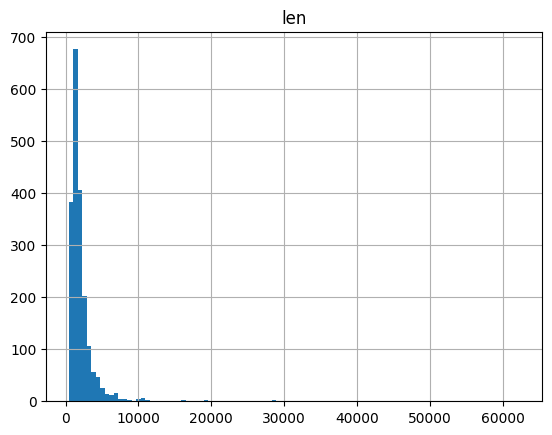

In [6]:
df.hist(bins=100)

array([[<Axes: title={'center': 'alt.atheism'}>,
        <Axes: title={'center': 'comp.graphics'}>,
        <Axes: title={'center': 'comp.os.ms-windows.misc'}>,
        <Axes: title={'center': 'comp.sys.ibm.pc.hardware'}>],
       [<Axes: title={'center': 'comp.sys.mac.hardware'}>,
        <Axes: title={'center': 'comp.windows.x'}>,
        <Axes: title={'center': 'misc.forsale'}>,
        <Axes: title={'center': 'rec.autos'}>],
       [<Axes: title={'center': 'rec.motorcycles'}>,
        <Axes: title={'center': 'rec.sport.baseball'}>,
        <Axes: title={'center': 'rec.sport.hockey'}>,
        <Axes: title={'center': 'sci.crypt'}>],
       [<Axes: title={'center': 'sci.electronics'}>,
        <Axes: title={'center': 'sci.med'}>,
        <Axes: title={'center': 'sci.space'}>,
        <Axes: title={'center': 'soc.religion.christian'}>],
       [<Axes: title={'center': 'talk.politics.guns'}>,
        <Axes: title={'center': 'talk.politics.mideast'}>,
        <Axes: title={'center': 'ta

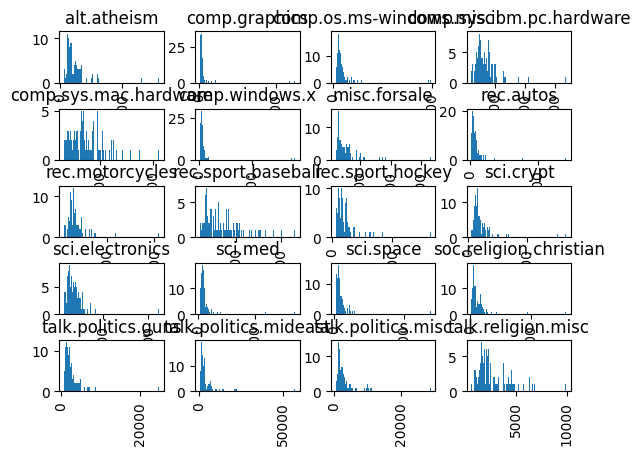

In [7]:
df.hist('len',by='Labels',bins=100)

In [8]:
df['len'].describe()

count     2000.000000
mean      2324.978000
std       3590.560226
min        425.000000
25%       1147.000000
50%       1605.500000
75%       2374.500000
max      62290.000000
Name: len, dtype: float64

In [9]:
import nltk

# Suppress download messages
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)

True

In [10]:
# checking

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.corpus import wordnet

# Tokenize
print(word_tokenize("Hello Priyanka, NLTK is working fine!"))

# Stopwords
print(stopwords.words("english")[:10])

# WordNet Synsets
print(wordnet.synsets("computer")[:5])

['Hello', 'Priyanka', ',', 'NLTK', 'is', 'working', 'fine', '!']
['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an']
[Synset('computer.n.01'), Synset('calculator.n.01')]


In [11]:
!pip install spacy

In [12]:
!pip install wordcloud

In [13]:
!python -m spacy download en_core_web_sm

     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     -- ------------------------------------- 0.8/12.8 MB 6.8 MB/s eta 0:00:02
     ----- ---------------------------------- 1.8/12.8 MB 7.8 MB/s eta 0:00:02
     --------- ------------------------------ 3.1/12.8 MB 5.9 MB/s eta 0:00:02
     ------------- -------------------------- 4.2/12.8 MB 6.2 MB/s eta 0:00:02
     ------------------ --------------------- 6.0/12.8 MB 5.6 MB/s eta 0:00:02
     ---------------------- ----------------- 7.3/12.8 MB 5.9 MB/s eta 0:00:01
     --------------------------- ------------ 8.9/12.8 MB 6.0 MB/s eta 0:00:01
     ------------------------------- -------- 10.0/12.8 MB 5.9 MB/s eta 0:00:01
     ---------------------------------- ----- 11.0/12.8 MB 5.7 MB/s eta 0:00:01
     -------------------------------------- - 12.3/12.8 MB 5.8 MB/s eta 0:00:01
     ---------------------------------------- 12.8/12.8 MB 5.5 MB/s eta 0:00:00
[+] Download and installation successful
You can now lo

In [14]:
nltk.download('punkt' , quiet=True)

True

In [15]:
nltk.download('stopwords' , quiet=True)

True

In [16]:
import re
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score,classification_report

In [17]:
def preprocess_text(text):
    # Convert text to lowercase
    text = text.lower()
    # Remove punctuation
    text = re.sub(r'[^\w\s]', '', text)
    # Tokenization
    tokens = nltk.word_tokenize(text)
    # Remove stopwords
    stopwords_list = set(stopwords.words('english'))
    tokens = [word for word in tokens if word not in stopwords_list]
    # Join tokens back into text
    text = ' '.join(tokens)
    return text

In [18]:
#Apply text preprocessing to the 'text' column
df['cleaned_text']=df['Data'].apply(preprocess_text)

In [19]:
#Feature extraction using TF-IDF
tfidf_vec=TfidfVectorizer(max_features=5000)
tfidf_vec

,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None
,"analyzer analyzer: {'word', 'char', 'char_wb'} or callable, default='word'Whether the feature should be made of word or character n-grams.Option 'char_wb' creates character n-grams only from text insideword boundaries; n-grams at the edges of words are padded with space.If a callable is passed it is used to extract the sequence of featuresout of the raw, unprocessed input... versionchanged:: 0.21 Since v0.21, if ``input`` is ``'filename'`` or ``'file'``, the data is first read from the file and then passed to the given callable analyzer.",'word'
,"stop_words stop_words: {'english'}, list, default=NoneIf a string, it is passed to _check_stop_list and the appropriate stoplist is returned. 'english' is currently the only supported stringvalue.There are several known issues with 'english' and you shouldconsider an alternative (see :ref:`stop_words`).If a list, that list is assumed to contain stop words, all of whichwill be removed from the resulting tokens.Only applies if ``analyzer == 'word'``.If None, no stop words will be used. In this case, setting `max_df`to a higher value, such as in the range (0.7, 1.0), can automatically detectand filter stop words based on intra corpus document frequency of terms.",None
,"token_pattern token_pattern: str, default=r""(?u)\\b\\w\\w+\\b""Regular expression denoting what constitutes a ""token"", only usedif ``analyzer == 'word'``. The default regexp selects tokens of 2or more alphanumeric characters (punctuation is completely ignoredand always treated as a token separator).If there is a capturing group in token_pattern then thecaptured group content, not the entire match, becomes the token.At most one capturing group is permitted.",'(?u)\\b\\w\\w+\\b'
,"ngram_range ngram_range: tuple (min_n, max_n), default=(1, 1)The lower and upper boundary of the range of n-values for differentn-grams to be extracted. All values of n such that min_n <= n <= max_nwill be used. For example an ``ngram_range`` of ``(1, 1)`` means onlyunigrams, ``(1, 2)`` means unigrams and bigrams, and ``(2, 2)`` meansonly bigrams.Only applies if ``analyzer`` is not callable.","(1

In [20]:
a=tfidf_vec.fit_transform(df['cleaned_text'])

In [21]:
a

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 187363 stored elements and shape (2000, 5000)>

In [22]:
b=df['Labels']

In [23]:
b

0              alt.atheism
1              alt.atheism
2              alt.atheism
3              alt.atheism
4              alt.atheism
               ...        
1995    talk.religion.misc
1996    talk.religion.misc
1997    talk.religion.misc
1998    talk.religion.misc
1999    talk.religion.misc
Name: Labels, Length: 2000, dtype: object

In [24]:
#splitting the data into training and testing data
x_train,x_test,y_train,y_test=train_test_split(a,b,test_size=0.75,random_state=100)

In [25]:
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(500, 5000)
(500,)
(1500, 5000)
(1500,)


In [26]:
#using NaiveBayes algorithm
naive_bayes=MultinomialNB()

In [27]:
naive_bayes.fit(x_train,y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [28]:
# predicting the data
y_pred=naive_bayes.predict(x_test)

In [29]:
y_pred

array(['rec.sport.hockey', 'sci.electronics', 'rec.motorcycles', ...,
       'rec.autos', 'comp.sys.mac.hardware', 'sci.space'],
      shape=(1500,), dtype='<U24')

In [30]:
#  finding performance metrics using accuracy score,precision,recall and f1 score
accuracy_score(y_test,y_pred)

0.47

In [31]:
classification_report(y_test,y_pred)

'                          precision    recall  f1-score   support\n\n             alt.atheism       0.27      0.91      0.41        69\n           comp.graphics       0.84      0.34      0.49        76\n comp.os.ms-windows.misc       1.00      0.06      0.11        82\ncomp.sys.ibm.pc.hardware       0.51      0.57      0.54        74\n   comp.sys.mac.hardware       0.66      0.76      0.71        71\n          comp.windows.x       0.00      0.00      0.00        83\n            misc.forsale       0.49      0.91      0.64        70\n               rec.autos       0.13      0.97      0.23        66\n         rec.motorcycles       0.85      0.79      0.81        70\n      rec.sport.baseball       1.00      0.17      0.30        80\n        rec.sport.hockey       0.87      0.70      0.77        76\n               sci.crypt       1.00      0.10      0.18        83\n         sci.electronics       0.76      0.48      0.59        73\n                 sci.med       0.79      0.79      0.79    

In [32]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer

In [33]:
#!python -m nltk.downloader vader_lexicon

In [34]:
#sentiment Analysis
sent_analy=SentimentIntensityAnalyzer()

In [35]:
sentiments=[]
for text in df['Data']:
  sentiment_scr=sent_analy.polarity_scores(text)
  if sentiment_scr['compound']>0:
    sentiments.append('positive+ve')
  elif sentiment_scr['compound']<0:
    sentiments.append('negative-ve')
  else:
    sentiments.append('neutral')

In [36]:
# adding sentiments to the data
df['sentiment']=sentiments

In [37]:
#Examining the distribution of sentiments
sentiment_dist=df.groupby(['Labels','sentiment']).size().unstack(fill_value=0)
print("\n sentiment Distribution Across Categories:")
print(sentiment_dist)


 sentiment Distribution Across Categories:
sentiment                 negative-ve  neutral  positive+ve
Labels                                                     
alt.atheism                        42        1           57
comp.graphics                      13        4           83
comp.os.ms-windows.misc            24        2           74
comp.sys.ibm.pc.hardware           21        0           79
comp.sys.mac.hardware              24        3           73
comp.windows.x                     20        2           78
misc.forsale                        7        8           85
rec.autos                          27        1           72
rec.motorcycles                    30        2           68
rec.sport.baseball                 27        1           72
rec.sport.hockey                   28        1           71
sci.crypt                          29        0           71
sci.electronics                    18        4           78
sci.med                            38        1          

In [38]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score

In [39]:
# Naive Bayes Classifier and performance metrics
accuracy_scr=accuracy_score(y_test,y_pred)
accuracy_scr

0.47

In [40]:
precision_scr=precision_score(y_test,y_pred,average='weighted')
precision_scr

0.7104055544925614

In [41]:
recall_scr=recall_score(y_test,y_pred,average='weighted')
recall_scr

0.47

In [42]:
f1_scr=f1_score(y_test,y_pred,average="weighted")
f1_scr

0.46174536564023744